<a href="https://colab.research.google.com/github/parkcherry785-boop/2025.DM/blob/main/%EC%9D%B4%EC%82%B0%EC%88%98%ED%95%99_5%EC%A1%B0_%EC%8B%A4%EC%8A%B5%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#친구관계 그래프

from collections import deque  #BFS 탐색 시 큐 사용을 위해 import

graph = {
    '박희서': ['윤준서', '김미서', '황정민'],
    '박채리': ['김다솜', '조수윤', '권민서'],
    '윤준서': ['이승현', '양예진', '강건우'],
    '양예진': ['박채리', '하효주', '김성경'],
    '김미서': [],
    '황정민': [],
    '이승현': [],
    '강건우': [],
    '하효주': [],
    '김성경': [],
    '김다솜': [],
    '조수윤': [],
    '권민서': []
}


# ----------------
# 깊이 우선 탐색(DFS)
# ----------------
def dfs(graph, v, visited) :
  visited. add(v)   #현재 노드 방문 표시
  print (v, end=' ')   #현재 노드 출력
  for neighbor in graph[v]:   #현재 노드와 연결된 이웃 노드들을 순서대로 탐색(연결된 친구들 확인)
    if neighbor not in visited:   #아직 방문하지 않은 노드라면 재귀적으로 DFS 수행
      dfs(graph, neighbor, visited)

print ("DFS 탐색 순서:")
dfs(graph, '박희서' , set ())   #'박희서'부터 시작


# ----------------
# 너비 우선 탐색(BFS)
# ----------------
def bfs(graph, start):
  visited = set()   #방문한 노드를 저장
  queue = deque([start])  #큐 초기화(시작 노드 넣기)
  visited. add(start)

  #큐가 빌 때까지 반복
  while queue:
    v = queue.popleft()  #큐의 가장 앞쪽 원소 꺼내기
    print(v, end=' ')
    #현재 노드와 연결된 모든 이웃 노드 확인
    for neighbor in graph[v]:
      if neighbor not in visited:
        visited.add(neighbor)
        queue.append(neighbor)   #큐에 추가(차례로 탐색)

print("\nBFS 탐색 순서 :")
bfs(graph, '박희서')

DFS 탐색 순서:
박희서 윤준서 이승현 양예진 박채리 김다솜 조수윤 권민서 하효주 김성경 강건우 김미서 황정민 
BFS 탐색 순서 :
박희서 윤준서 김미서 황정민 이승현 양예진 강건우 박채리 하효주 김성경 김다솜 조수윤 권민서 

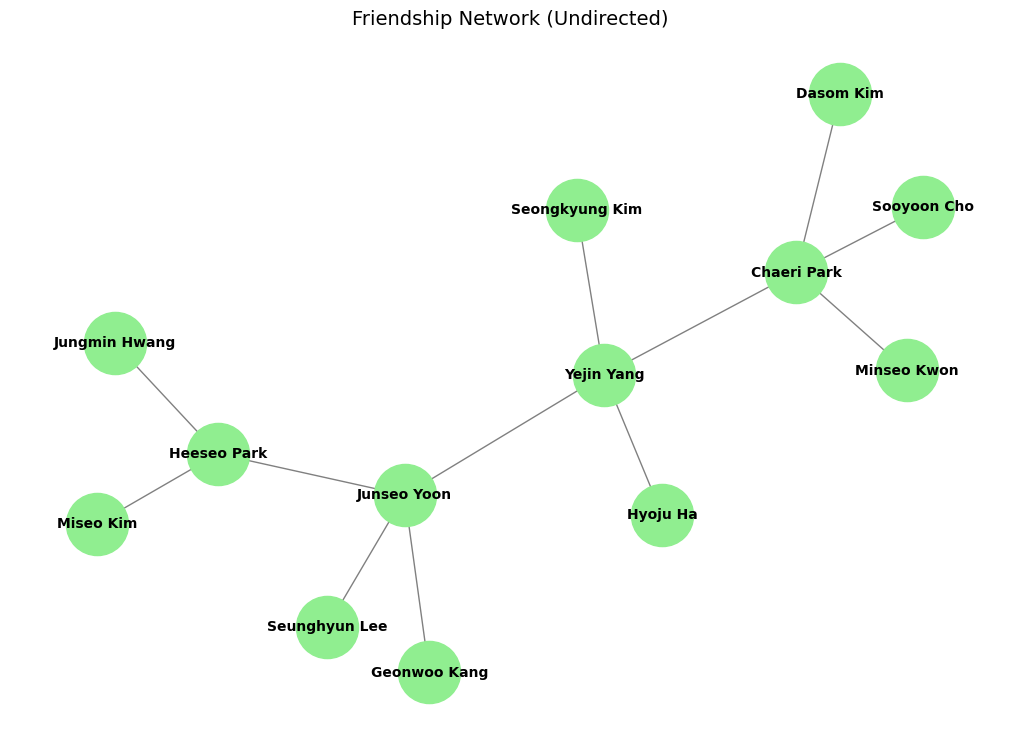

In [ ]:
#networkx 시각화
import networkx as nx
import matplotlib.pyplot as plt

# 친구 관계 그래프 (영문)
graph = {
    'Heeseo Park': ['Junseo Yoon', 'Miseo Kim', 'Jungmin Hwang'],
    'Chaeri Park': ['Dasom Kim', 'Sooyoon Cho', 'Minseo Kwon'],
    'Junseo Yoon': ['Seunghyun Lee', 'Yejin Yang', 'Geonwoo Kang'],
    'Yejin Yang': ['Chaeri Park', 'Hyoju Ha', 'Seongkyung Kim'],
    'Miseo Kim': [],
    'Jungmin Hwang': [],
    'Seunghyun Lee': [],
    'Geonwoo Kang': [],
    'Hyoju Ha': [],
    'Seongkyung Kim': [],
    'Dasom Kim': [],
    'Sooyoon Cho': [],
    'Minseo Kwon': []
}

# 무방향 그래프 생성
G = nx.Graph()

# 노드와 엣지 추가 (양방향 연결)
for person, friends in graph.items():
    for friend in friends:
        G.add_edge(person, friend)

# 레이아웃 설정 (spring_layout이 보기 좋음)
pos = nx.spring_layout(G, seed=42)

# 그래프 시각화
plt.figure(figsize=(10, 7))
nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightgreen",
    node_size=2000,
    font_size=10,
    font_weight="bold",
    edge_color="gray"
)

plt.title("Friendship Network (Undirected)", fontsize=14)
plt.show()

In [ ]:
#감염자 확산단계 표시
from collections import deque

# 1. (노드 10개)
graph = {
    '박희서': ['윤준서', '김미서'],
    '박채리': ['김다솜', '권민서'],
    '윤준서': ['이승현', '양예진'],
    '양예진': ['박채리', '하효주', '김성경'],
    '김미서': ['김성경'],
    '이승현': ['윤준서'],
    '하효주': ['권민서'],
    '김성경': ['양예진','하효주'],
    '김다솜': ['윤준서'],
    '권민서': []
}
def trace_infection(graph, start):
  """
  BFS를 사용해 'start' 노드로부터 2단계 이내의 모든 노드를
  거리(레벨)와 함께 출력합니다. (시작 노드 제외)
  """
  visited = set()
  # 큐에 (노드, 깊이)를 함께 저장
  queue = deque([(start, 0)])
  visited.add(start)

  print(f"\n'{start}'로부터 2단계 이내 전염 경로 추적:")

  while queue:
    v, depth = queue.popleft() # 깊이(depth)도 함께 꺼냄

    # 요구사항: 2단계 이내(1, 2단계) 노드 출력, 감염자 자신(0단계) 제외
    if depth > 0 and depth <= 2:
      print(f"- {v} (거리: {depth}단계)")

    # 요구사항: max depth 2. (depth < 2일 때만 이웃을 큐에 추가)
    if depth < 2:
      for neighbor in graph[v]:
        if neighbor not in visited:
          visited.add(neighbor)
          # 다음 이웃의 깊이는 현재 깊이 + 1
          queue.append((neighbor, depth + 1))

# --- 실행 ---
# '하' 단계 테스트 케이스 실행 (최초 감염자: '박희서')
trace_infection(graph, '박희서')


'박희서'로부터 2단계 이내 전염 경로 추적:
- 윤준서 (거리: 1단계)
- 김미서 (거리: 1단계)
- 이승현 (거리: 2단계)
- 양예진 (거리: 2단계)
- 김성경 (거리: 2단계)


In [ ]:
from collections import deque
# deque는 양쪽에서 빠르게 요소를 추가/제거할 수 있는 자료구조
# BFS(너비우선탐색)에서 큐로 사용하면 O(1) 시간에 push/pop이 가능

# (노드 100개)
graph = {
    "박희서": {"윤준서", "김미서", "황정민", "박채리", "김다솜"},
    "윤준서": {"박희서", "이승현", "류재윤", "박채리"},
    "김미서": {"박희서", "권민서", "김다솜"},
    "황정민": {"박희서", "류재윤", "이승현"},
    "박채리": {"윤준서", "조수윤", "박희서", "이소민"},
    "김다솜": {"김미서", "권민서", "조수윤", "송지훈"},
    "조수윤": {"박채리", "김다솜", "정예린", "장민석"},
    "권민서": {"김미서", "김다솜", "이승현"},
    "이승현": {"윤준서", "황정민", "권민서", "류재윤", "정예린"},
    "류재윤": {"황정민", "이승현", "박희서", "송지훈"},
    "송지훈": {"류재윤", "김다솜", "문지윤", "한승우"},
    "이민아": {"박서진", "최다인", "정예린"},
    "박서진": {"이민아", "남도윤", "백승민", "장민석"},
    "최다인": {"이민아", "정예린", "한승우"},
    "정예린": {"이민아", "최다인", "이승현", "조수윤", "한승우"},
    "한승우": {"최다인", "정예린", "송지훈"},
    "남도윤": {"박서진", "배소율", "홍지아", "임지연"},
    "배소율": {"남도윤", "홍지아", "장민석"},
    "홍지아": {"배소율", "남도윤", "임지연"},
    "장민석": {"조수윤", "박서진", "배소율"},
    "오서현": {"문지윤", "양지후", "정민재"},
    "문지윤": {"송지훈", "오서현", "백승민"},
    "양지후": {"오서현", "정민재", "임지연"},
    "백승민": {"문지윤", "박서진"},
    "임지연": {"남도윤", "홍지아", "양지후"},
    "노현우": {"이소민", "윤가현", "고도현"},
    "이소민": {"노현우", "박채리"},
    "윤가현": {"노현우", "하수빈", "차지우"},
    "고도현": {"노현우", "차지우", "정민재"},
    "차지우": {"고도현", "윤가현"},
    "하수빈": {"윤가현", "유시현", "정민재"},
    "유시현": {"하수빈", "정민재"},
    "정민재": {"유시현", "오서현", "하수빈", "양지후", "고도현"},
    "서하윤": {"조나연", "박규리"},
    "조나연": {"서하윤", "이서준", "박규리"},
    "박규리": {"서하윤", "조나연", "최유리"},
    "이서준": {"조나연", "강하율"},
    "최유리": {"박규리", "강하율"},
    "강하율": {"이서준", "최유리", "류시훈"},
    "류시훈": {"강하율", "배윤호"},
    "배윤호": {"류시훈", "손주원", "김태윤"},
    "손주원": {"배윤호", "정서현"},
    "김태윤": {"배윤호", "정서현"},
    "정서현": {"손주원", "김태윤"},
    "오주하": {"권지민", "홍예담"},
    "권지민": {"오주하", "홍예담"},
    "홍예담": {"오주하", "권지민", "김세은"},
    "김세은": {"홍예담", "박하린"},
    "박하린": {"김세은", "이동현"},
    "이동현": {"박하린", "문지환"},
    "문지환": {"이동현", "강도형"},
    "강도형": {"문지환", "조다영"},
    "조다영": {"강도형", "이주원"},
    "이주원": {"조다영", "송현우"},
    "송현우": {"이주원", "한서윤"},
    "한서윤": {"송현우", "배지우"},
    "배지우": {"한서윤", "남하린"},
    "남하린": {"배지우", "윤성호"},
    "윤성호": {"남하린", "이유진"},
    "이유진": {"윤성호", "장유나"},
    "장유나": {"이유진", "박주원"},
    "박주원": {"장유나", "정하늘"},
    "정하늘": {"박주원", "김나연"},
    "김나연": {"정하늘", "백승하"},
    "백승하": {"김나연", "오지훈"},
    "오지훈": {"백승하", "서현우"},
    "서현우": {"오지훈", "김도현"},
    "김도현": {"서현우", "류유진"},
    "류유진": {"김도현", "조예은"},
    "조예은": {"류유진", "박정우"},
    "박정우": {"조예은", "최주하"},
    "최주하": {"박정우", "이서영"},
    "이서영": {"최주하", "강주원"},
    "강주원": {"이서영", "남서윤"},
    "남서윤": {"강주원", "홍지훈"},
    "홍지훈": {"남서윤", "김규리"},
    "김규리": {"홍지훈", "이도현"},
    "이도현": {"김규리", "박시윤"},
    "박시윤": {"이도현", "배정민"},
    "배정민": {"박시윤", "최서하"},
    "최서하": {"배정민", "이준호"},
    "이준호": {"최서하", "노유정"},
    "노유정": {"이준호", "김하은"},
    "김하은": {"노유정", "장서우"},
    "장서우": {"김하은", "한지후"},
    "한지후": {"장서우", "이민재"},
    "이민재": {"한지후", "서유정"},
    "서유정": {"이민재", "박소율"},
    "박소율": {"서유정", "조민혁"},
    "조민혁": {"박소율", "윤다인"},
    "윤다인": {"조민혁", "백주원"},
    "백주원": {"윤다인", "류하율"},
    "류하율": {"백주원", "정도윤"},
    "정도윤": {"류하율", "문하린"},
    "문하린": {"정도윤", "박채우"},
    "박채우": {"문하린", "홍지후"},
    "홍지후": {"박채우", "김도율"},
    "김도율": {"홍지후", "이예린"},
    "이예린": {"김도율", "오민재"},
    "오민재": {"이예린"}
}

# --------------------------------------------------------
# BFS(너비우선탐색)으로 감염 경로 추적 함수
# --------------------------------------------------------
def infection_trace(graph, infected, max_depth=10):
    """
    graph: dict -> 노드(사람 이름) : set(이웃 노드들)
    infected: str -> 최초 감염자 이름 (탐색 시작점)
    max_depth: int -> 탐색(감염)허용 최대 단계 (0이면 자기 자신만, 1이면 직접 이웃까지 등)

    동작 요약:
    - BFS를 이용해 'infected'에서 출발하여 단계별로 퍼져나가는 노드를 탐색
    - 방문(감염)한 노드는 visited 집합에 추가해 중복 처리(다중 경로로 인한 중복 출력)를 방지
    - 각 방문 시점에 (이웃, 현재 단계+1)을 큐에 넣고, 출력 시 거리를 함께 출력
    - 탐색은 max_depth에 도달한 노드의 이웃은 더 이상 확산x
    """

    # visited: 이미 확인(감염 처리)한 노드를 기록.
    # 초기에 최초 감염자만 포함. 이렇게 하면 최초 감염자가 다시 출력되지 않음.
    visited = {infected}

    # queue: (노드이름, 현재노드까지의 거리) 튜플을 저장.
    # 시작점은 (infected, 0) — 자기 자신은 거리 0.
    queue = deque([(infected, 0)])

    # 출력 헤더: 누구를 시작으로 하는지와 최대 몇 단계까지 추적하는지 알림.
    print(f"🦠 최초 감염자: {infected}")
    print(f"📍 최대 {max_depth}단계 이내 감염 경로:")

    # 큐가 빌 때까지 반복 — 표준 BFS 루프
    while queue:
        # 큐의 왼쪽(가장 먼저 들어온 항목)을 꺼냄 — FIFO
        current, depth = queue.popleft()

        # 현재 노드의 깊이가 이미 max_depth에 도달했으면
        # 이 노드의 이웃들은 더 이상 확산시키지 않음(깊이 제한).
        # (예: depth == max_depth이면 이 노드는 허용되나, 자식 노드(depth+1)는 허용 안 됨)
        if depth == max_depth:
            # continue로 루프의 다음 반복으로 넘어감 — 해당 노드의 이웃 탐색을 건너뜀
            continue

        # 현재 노드의 모든 이웃(친구)들을 탐색
        # graph.get(current, [])를 사용해 안전하게 이웃을 가져옴
        # 만약 current가 graph에 없으면 빈 반복([])으로 처리되어 KeyError를 방지.
        for neighbor in graph.get(current, []):
            # 중복 방문(이미 감염 처리된 사람)을 피하기 위해 visited 확인
            if neighbor not in visited:
                # 아직 방문하지 않은 사람이면 방문 처리
                visited.add(neighbor)               # 재방문을 막기 위해 먼저 visited에 추가
                queue.append((neighbor, depth + 1)) # 큐에 (이웃, 현재 깊이+1)로 추가하여 이후에 그 이웃의 이웃을 탐색

                # 출력: 이웃은 'depth + 1' 단계에서 감염될 수 있음
                print(f"  - {neighbor} (거리: {depth + 1}단계)")

# --------------------------------------------------------
# 실행
# --------------------------------------------------------
# "박채리"를 최초 감염자로 지정하고, 최대 10단계까지 추적 실행
infection_trace(graph, "박채리", max_depth=10)


🦠 최초 감염자: 박채리
📍 최대 10단계 이내 감염 경로:
  - 조수윤 (거리: 1단계)
  - 이소민 (거리: 1단계)
  - 윤준서 (거리: 1단계)
  - 박희서 (거리: 1단계)
  - 정예린 (거리: 2단계)
  - 김다솜 (거리: 2단계)
  - 장민석 (거리: 2단계)
  - 노현우 (거리: 2단계)
  - 류재윤 (거리: 2단계)
  - 이승현 (거리: 2단계)
  - 김미서 (거리: 2단계)
  - 황정민 (거리: 2단계)
  - 이민아 (거리: 3단계)
  - 한승우 (거리: 3단계)
  - 최다인 (거리: 3단계)
  - 송지훈 (거리: 3단계)
  - 권민서 (거리: 3단계)
  - 박서진 (거리: 3단계)
  - 배소율 (거리: 3단계)
  - 고도현 (거리: 3단계)
  - 윤가현 (거리: 3단계)
  - 문지윤 (거리: 4단계)
  - 남도윤 (거리: 4단계)
  - 백승민 (거리: 4단계)
  - 홍지아 (거리: 4단계)
  - 정민재 (거리: 4단계)
  - 차지우 (거리: 4단계)
  - 하수빈 (거리: 4단계)
  - 오서현 (거리: 5단계)
  - 임지연 (거리: 5단계)
  - 양지후 (거리: 5단계)
  - 유시현 (거리: 5단계)


In [ ]:
# --- 0. 모듈 불러오기 ---
import random  # 랜덤 그래프 생성을 위해 import
from collections import deque  # BFS(너비 우선 탐색)를 위한 큐(Queue) 자료구조

# --- 1. 고정된 그래프 생성을 위한 시드(Seed) 설정 ---
# '랜덤 시드'를 42로 고정합니다. 숫자는 아무 숫자나 상관없음
# 이 코드는 이제 실행할 때마다 항상 '똑같은' 고정된 그래프를 생성합니다.
random.seed(42)

# --- 2. 100명의 이름 리스트 (노드) ---
all_names = [
    '박희서', '박채리', '윤준서', '양예진', '김미서', '황정민', '이승현', '강건우',
    '하효주', '김성경', '김다솜', '조수윤', '권민서', '김민준', '이서연', '박지훈',
    '최수빈', '정예은', '강지호', '조은우', '윤하늘', '장도현', '임서아', '한유준',
    '오지아', '서예준', '신하윤', '권시우', '송지민', '안재윤', '홍채원', '전주원',
    '문서윤', '양지원', '배성민', '백민서', '유승우', '노유진', '하선우', '천정우',
    '방예린', '성현우', '차다은', '고은성', '위지훈', '구민재', '추지우', '편도윤',
    '남궁준', '독고진', '제갈현', '황보름', '선우휘', '김이안', '이로운', '박라온',
    '최다온', '정시윤', '강서준', '조하준', '윤은채', '장아인', '임지유', '한아윤',
    '오서아', '서이서', '신나은', '권도하', '송지환', '안태민', '홍준우', '전성현',
    '문채아', '양소율', '배윤아', '백승현', '유예나', '노하율', '하예진', '천우진',
    '방준서', '성지안', '차민호', '고태현', '위가은', '구다연', '추민준', '편지호',
    '남궁민', '독고율', '제갈빈', '황보윤', '선우찬', '김태리', '이보검', '박서준',
    '최우식', '정유미'
]

# --- 3. 고정된 그래프 생성 함수 ---
def create_fixed_graph(nodes, min_conn, max_conn):
    """
    이름 리스트(nodes)를 받아 '고정된' 인접 리스트(그래프)를 생성합니다.
    그래프는 { '이름': ['친구1', '친구2'], ... } 형태의 딕셔너리입니다.
    """
    # 1. 각 노드의 친구 리스트를 빈 리스트로 초기화
    graph = {node: [] for node in nodes}

    # 2. 각 사람마다 랜덤(시드 고정)으로 친구 수를 정해 연결을 생성
    for node in nodes:
        num_connections = random.randint(min_conn, max_conn)
        possible_connections = [n for n in nodes if n != node]
        actual_connections_count = min(num_connections, len(possible_connections))
        connections = random.sample(possible_connections, actual_connections_count)

        # 3. 양방향(무방향처럼) 연결 추가
        for friend in connections:
            if friend not in graph[node]:
                graph[node].append(friend)
            if node not in graph[friend]:
                graph[friend].append(node)

    return graph

# --- 4. 감염 경로 추적 함수 (BFS) ---
def trace_infection(graph, start, max_depth):
    """
    BFS(너비 우선 탐색)를 사용해 'start' 노드로부터
    'max_depth' 이내의 모든 노드를 거리(레벨)와 함께 출력합니다.

    - graph: dict {node: [neighbors,...]}
    - start: 시작 노드(최초 감염자, str)
    - max_depth: 탐색 허용 최대 단계 (int)
    """
    # 'visited'는 이미 큐에 넣었거나 출력한 노드를 기록해서 중복 방지를 함
    visited = set()

    # 큐에는 (노드, 현재깊이) 튜플을 넣음. 시작 노드는 깊이 0
    queue = deque([(start, 0)])

    # 시작 노드는 방문 처리 (다시 출력되지 않도록)
    visited.add(start)

    print(f"\n---'{start}'로부터 {max_depth}단계 이내 전염 경로 추적 ---")

    found_contacts = 0  # 발견된 접촉자 수 (출력용)

    # BFS 루프: 큐가 빌 때까지 반복
    while queue:
        # FIFO: 왼쪽에서 꺼냄
        v, depth = queue.popleft()

        # depth가 0보다 크고(max_depth 이하)이면 출력 — 감염자 자신(depth 0) 제외
        if depth > 0 and depth <= max_depth:
            print(f"- {v} (거리: {depth}단계)")
            found_contacts += 1

        # 현재 깊이가 max_depth보다 작을 때만 이웃(다음 깊이)을 큐에 추가
        if depth < max_depth:
            for neighbor in graph[v]:
                # 아직 방문하지 않은 노드만 큐에 추가
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append((neighbor, depth + 1))

    # 만약 아무도 발견되지 않았으면 알림 출력
    if found_contacts == 0:
        print(f"'{start}'로부터 {max_depth}단계 이내 접촉자가 없습니다.")


# --- 5. 코드 실행 부분 ---

print(f"총 {len(all_names)}명의 이름으로 '고정된' 그래프를 생성합니다.")

# 1. 100명 인접 리스트(그래프) 생성 (각 노드당 min_conn~max_conn 친구 수)
graph = create_fixed_graph(all_names, min_conn=2, max_conn=5)

# (선택 사항) 생성된 전체 그래프를 보고 싶으면 아래 주석 해제
# print("="*40)
# print("--- 📄 생성된 100명 전체 인접 리스트 (고정됨) ---")
# for name in graph:
#     print(f"'{name}': {graph[name]}")
# print("="*40)

# 2. 시뮬레이션 실행 (최초 감염자: '황정민', 최대 깊이: 10)
start_node = '황정민'
max_level = 10
trace_infection(graph, start_node, max_level)

총 98명의 이름으로 '고정된' 그래프를 생성합니다.

---'황정민'로부터 10단계 이내 전염 경로 추적 ---
- 홍채원 (거리: 1단계)
- 서이서 (거리: 1단계)
- 하예진 (거리: 1단계)
- 조수윤 (거리: 1단계)
- 이서연 (거리: 1단계)
- 박서준 (거리: 1단계)
- 박지훈 (거리: 2단계)
- 조은우 (거리: 2단계)
- 성지안 (거리: 2단계)
- 성현우 (거리: 2단계)
- 차다은 (거리: 2단계)
- 유예나 (거리: 2단계)
- 노유진 (거리: 2단계)
- 하선우 (거리: 2단계)
- 이승현 (거리: 2단계)
- 위가은 (거리: 2단계)
- 배윤아 (거리: 2단계)
- 구민재 (거리: 2단계)
- 방준서 (거리: 2단계)
- 김다솜 (거리: 2단계)
- 남궁민 (거리: 2단계)
- 배성민 (거리: 2단계)
- 신나은 (거리: 2단계)
- 김성경 (거리: 2단계)
- 황보윤 (거리: 2단계)
- 하효주 (거리: 2단계)
- 백민서 (거리: 2단계)
- 정유미 (거리: 2단계)
- 박희서 (거리: 2단계)
- 박채리 (거리: 2단계)
- 윤준서 (거리: 2단계)
- 최수빈 (거리: 2단계)
- 남궁준 (거리: 3단계)
- 노하율 (거리: 3단계)
- 차민호 (거리: 3단계)
- 전성현 (거리: 3단계)
- 김민준 (거리: 3단계)
- 선우휘 (거리: 3단계)
- 양지원 (거리: 3단계)
- 제갈현 (거리: 3단계)
- 이보검 (거리: 3단계)
- 한유준 (거리: 3단계)
- 편도윤 (거리: 3단계)
- 천정우 (거리: 3단계)
- 임서아 (거리: 3단계)
- 방예린 (거리: 3단계)
- 양소율 (거리: 3단계)
- 이로운 (거리: 3단계)
- 양예진 (거리: 3단계)
- 강건우 (거리: 3단계)
- 황보름 (거리: 3단계)
- 편지호 (거리: 3단계)
- 서예준 (거리: 3단계)
- 문채아 (거리: 3단계)
- 신하윤 (거리: 3단계)
- 안재윤 (거리: 3단계)
- 김태리 (거리: 3단계)
- 윤은채 (거리: 3단계)
- 송지환 (거